# Step 5 — Porównanie domen: Filmweb vs Sport

Czy wyniki ekstrakcji grafów wiedzy generalizują się na nową domenę?  
4 modele × 2 domeny (filmweb + sport) × 8 artykułów każda = 64 obserwacje.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from IPython.display import display, HTML

COLS = ["position", "id", "title", "model", "prompt",
        "precision", "recall", "hall", "miss",
        "t_precision", "t_recall", "t_hall", "t_miss", "connectivity"]

df = pd.read_csv("step_5_more_domains.csv", header=None, names=COLS)

def short_label(m):
    if "/" in m:
        m = m.rsplit("/", 1)[-1]
    return m

df["model_short"] = df["model"].apply(short_label)
df["title_short"] = df["title"].str.replace("_", " ").str[:40]
df["domain"] = df["prompt"].apply(lambda p: "Sport" if p.startswith("sport") else "Filmweb")

df["t_f1"] = 2 * df["t_precision"] * df["t_recall"] / (df["t_precision"] + df["t_recall"])
df["f1"]   = 2 * df["precision"]   * df["recall"]   / (df["precision"]   + df["recall"])

TOP4 = ["gemma-4-26b-a4b-it", "gemma-4-31b-it", "mistral-small-3.2-24b-instruct", "qwen3-32b"]
MODEL_COLORS = {
    "gemma-4-26b-a4b-it":             "#e41a1c",
    "gemma-4-31b-it":                 "#377eb8",
    "mistral-small-3.2-24b-instruct": "#4daf4a",
    "qwen3-32b":                      "#984ea3",
}
DOMAIN_COLORS = {"Filmweb": "#4878d0", "Sport": "#ee854a"}
DOMAIN_ROW_COLORS = {"Filmweb": "#eef3fb", "Sport": "#fff8f2"}

def color_domain(row):
    color = DOMAIN_ROW_COLORS.get(row.get("Domena", row.get("domain", "")), "")
    return [f"background-color: {color}" for _ in row]

NUMERIC = ["precision", "recall", "f1", "t_precision", "t_recall", "t_f1", "connectivity"]

print(f"{len(df)} wierszy | {df['model_short'].nunique()} modele | {df['domain'].value_counts().to_dict()}")
display(df.groupby("domain")[NUMERIC].mean().round(3).style.background_gradient(cmap="RdYlGn", vmin=0, vmax=1).format("{:.1%}"))

64 wierszy | 4 modele | {'Sport': 32, 'Filmweb': 32}


,precision,recall,f1,t_precision,t_recall,t_f1,connectivity
domain,,,,,,,
Filmweb,93.8%,71.1%,80.0%,83.5%,75.6%,76.7%,82.0%
Sport,75.8%,65.0%,68.9%,77.6%,80.6%,77.2%,88.0%


## Średnie per model × domena

In [4]:
for sort_col, label in [("t_f1", "T-F1"), ("t_precision", "T-Precision"), ("precision", "Precision")]:
    display(HTML(f"<h4>Ranking wg {label}</h4>"))
    summary = (
        df.groupby(["model_short", "domain"])[NUMERIC]
        .mean()
        .round(3)
        .reset_index()
        .sort_values(["model_short", sort_col], ascending=[True, False])
    )
    summary = summary.rename(columns={"model_short": "Model", "domain": "Domena"})
    display(
        summary.style
        .apply(color_domain, axis=1)
        .background_gradient(subset=NUMERIC, cmap="RdYlGn", vmin=0, vmax=1)
        .format({c: "{:.1%}" for c in NUMERIC})
        .hide(axis="index")
        .set_table_styles([{"selector": "th", "props": [("white-space", "nowrap")]}])
    )

Model,Domena,precision,recall,f1,t_precision,t_recall,t_f1,connectivity
gemma-4-26b-a4b-it,Filmweb,97.5%,67.3%,79.2%,92.3%,76.4%,82.8%,68.9%
gemma-4-26b-a4b-it,Sport,77.9%,64.8%,70.4%,83.2%,84.1%,82.7%,87.6%
gemma-4-31b-it,Filmweb,96.6%,69.9%,80.1%,96.8%,74.7%,83.0%,84.7%
gemma-4-31b-it,Sport,89.4%,65.0%,74.2%,91.9%,77.2%,82.8%,89.3%
mistral-small-3.2-24b-instruct,Filmweb,88.4%,76.6%,81.4%,67.8%,84.3%,71.5%,84.7%
mistral-small-3.2-24b-instruct,Sport,67.8%,69.6%,68.5%,63.9%,83.9%,70.8%,93.8%
qwen3-32b,Sport,68.1%,60.5%,62.4%,71.5%,77.2%,72.6%,81.5%
qwen3-32b,Filmweb,92.7%,70.5%,79.4%,77.0%,66.9%,69.6%,89.7%


Model,Domena,precision,recall,f1,t_precision,t_recall,t_f1,connectivity
gemma-4-26b-a4b-it,Filmweb,97.5%,67.3%,79.2%,92.3%,76.4%,82.8%,68.9%
gemma-4-26b-a4b-it,Sport,77.9%,64.8%,70.4%,83.2%,84.1%,82.7%,87.6%
gemma-4-31b-it,Filmweb,96.6%,69.9%,80.1%,96.8%,74.7%,83.0%,84.7%
gemma-4-31b-it,Sport,89.4%,65.0%,74.2%,91.9%,77.2%,82.8%,89.3%
mistral-small-3.2-24b-instruct,Filmweb,88.4%,76.6%,81.4%,67.8%,84.3%,71.5%,84.7%
mistral-small-3.2-24b-instruct,Sport,67.8%,69.6%,68.5%,63.9%,83.9%,70.8%,93.8%
qwen3-32b,Filmweb,92.7%,70.5%,79.4%,77.0%,66.9%,69.6%,89.7%
qwen3-32b,Sport,68.1%,60.5%,62.4%,71.5%,77.2%,72.6%,81.5%


Model,Domena,precision,recall,f1,t_precision,t_recall,t_f1,connectivity
gemma-4-26b-a4b-it,Filmweb,97.5%,67.3%,79.2%,92.3%,76.4%,82.8%,68.9%
gemma-4-26b-a4b-it,Sport,77.9%,64.8%,70.4%,83.2%,84.1%,82.7%,87.6%
gemma-4-31b-it,Filmweb,96.6%,69.9%,80.1%,96.8%,74.7%,83.0%,84.7%
gemma-4-31b-it,Sport,89.4%,65.0%,74.2%,91.9%,77.2%,82.8%,89.3%
mistral-small-3.2-24b-instruct,Filmweb,88.4%,76.6%,81.4%,67.8%,84.3%,71.5%,84.7%
mistral-small-3.2-24b-instruct,Sport,67.8%,69.6%,68.5%,63.9%,83.9%,70.8%,93.8%
qwen3-32b,Filmweb,92.7%,70.5%,79.4%,77.0%,66.9%,69.6%,89.7%
qwen3-32b,Sport,68.1%,60.5%,62.4%,71.5%,77.2%,72.6%,81.5%


## Wykres porównawczy: Filmweb vs Sport (kluczowe metryki)

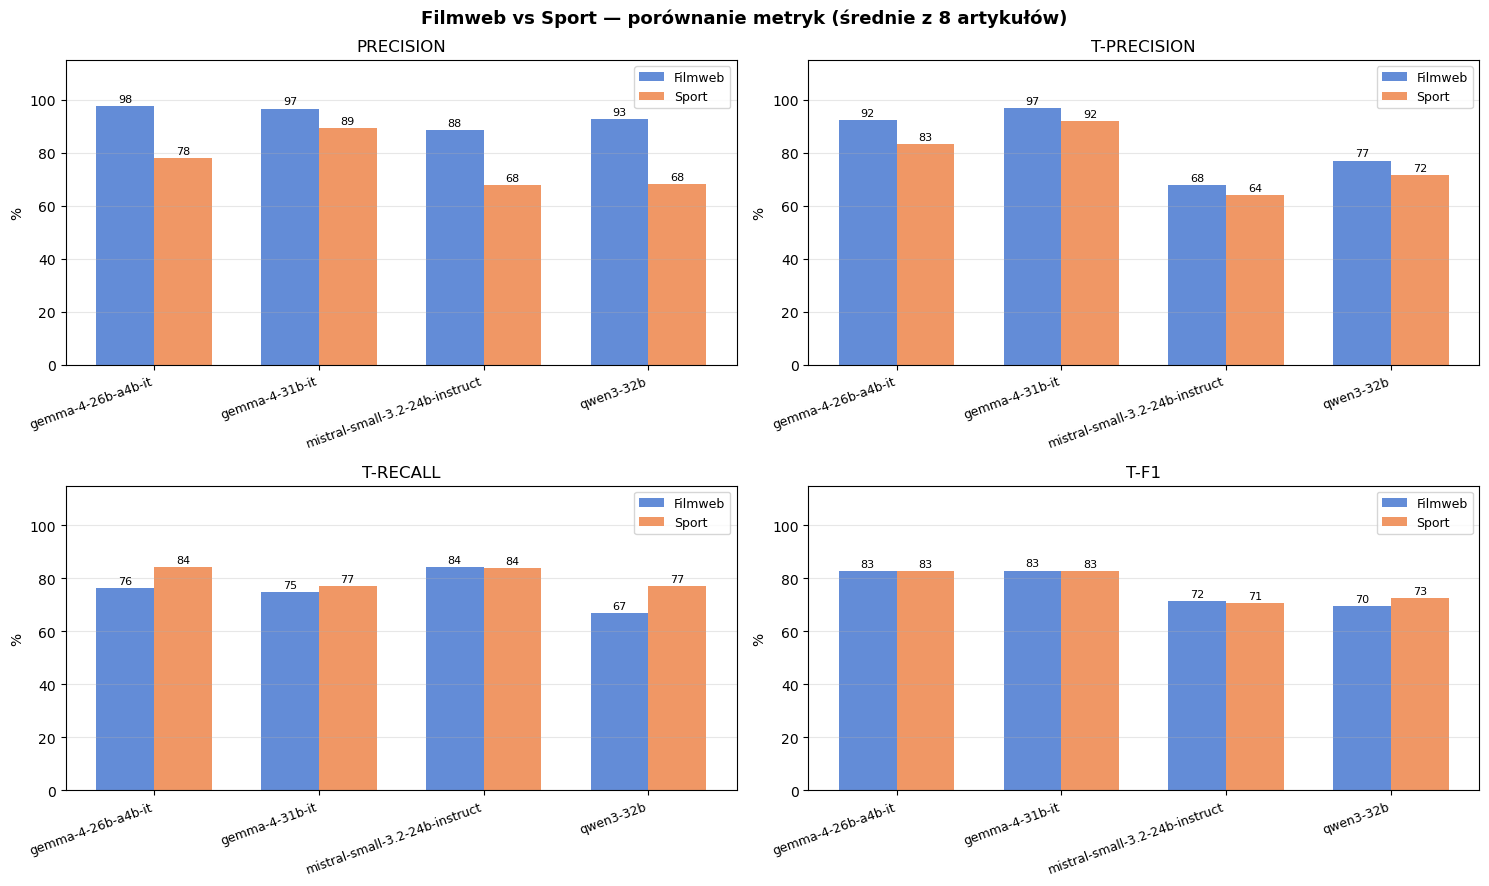

In [6]:
agg = df.groupby(["model_short", "domain"])[NUMERIC].mean().reset_index()
models = TOP4
model_labels = [short_label(m) for m in models]
x = np.arange(len(models))
w = 0.35

fig, axes = plt.subplots(2, 2, figsize=(15, 9))
axes = axes.flatten()

for ax, metric in zip(axes, ["precision", "t_precision", "t_recall", "t_f1"]):
    for i, domain in enumerate(["Filmweb", "Sport"]):
        vals = []
        for m in models:
            ms = short_label(m)
            row = agg[(agg["model_short"] == ms) & (agg["domain"] == domain)]
            vals.append(row[metric].values[0] * 100 if len(row) else 0)
        bars = ax.bar(x + (i - 0.5) * w, vals, w,
                      label=domain, color=DOMAIN_COLORS[domain], alpha=0.85)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
                    f"{v:.0f}", ha="center", va="bottom", fontsize=8)

    ax.set_xticks(x)
    ax.set_xticklabels(model_labels, rotation=20, ha="right", fontsize=9)
    ax.set_ylim(0, 115)
    ax.set_ylabel("%")
    ax.set_title(metric.replace("_", "-").upper())
    ax.legend(fontsize=9)
    ax.grid(axis="y", alpha=0.3)

fig.suptitle("Filmweb vs Sport — porównanie metryk (średnie z 8 artykułów)", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

## Tabela delta: zmiana Filmweb → Sport

In [8]:
agg_pivot = df.groupby(["model_short", "domain"])[NUMERIC].mean().unstack("domain").round(3)

delta_cols = ["precision", "t_precision", "t_recall", "t_f1", "connectivity"]
delta = pd.DataFrame(index=agg_pivot.index)
for c in delta_cols:
    delta[c] = agg_pivot[(c, "Sport")] - agg_pivot[(c, "Filmweb")]
delta = delta.round(3)
delta.index.name = "Model"
delta = delta.rename(columns={
    "precision": "ΔPrec.", "t_precision": "ΔT-Prec.",
    "t_recall": "ΔT-Recall", "t_f1": "ΔT-F1", "connectivity": "ΔConnect."
})

display(HTML("<h4>Delta Sport − Filmweb (dodatnia = Sport lepszy, ujemna = Sport gorszy)</h4>"))
display(
    delta.style
    .background_gradient(cmap="RdYlGn", vmin=-0.3, vmax=0.3)
    .format("{:+.1%}")
    .set_table_styles([{"selector": "th", "props": [("white-space", "nowrap")]}])
)

,ΔPrec.,ΔT-Prec.,ΔT-Recall,ΔT-F1,ΔConnect.
Model,,,,,
gemma-4-26b-a4b-it,-19.6%,-9.1%,+7.7%,-0.1%,+18.7%
gemma-4-31b-it,-7.2%,-4.9%,+2.5%,-0.2%,+4.6%
mistral-small-3.2-24b-instruct,-20.6%,-3.9%,-0.4%,-0.7%,+9.1%
qwen3-32b,-24.6%,-5.5%,+10.3%,+3.0%,-8.2%


## Heatmapa T-F1: model × artykuł (obie domeny)

In [10]:
for domain in ["Filmweb", "Sport"]:
    display(HTML(f"<h4>T-F1 — {domain}</h4>"))
    sub = df[df["domain"] == domain]
    pivot = sub.pivot_table(index="model_short", columns="title_short", values="t_f1")
    pivot["Średnia"] = pivot.mean(axis=1)
    display(
        pivot.style
        .background_gradient(cmap="RdYlGn", vmin=0, vmax=1)
        .format("{:.1%}")
        .set_table_styles([{"selector": "th", "props": [("white-space", "nowrap"), ("font-size", "10px")]}])
    )

title_short,Langer serial SkyShowtime,Maj w Prime Video. Jakie nowości zobaczy,Największe kino plenerowe w Polsce powra,Porzadny czlowiek - recenzujemy produkcj,Siedem nowych filmów w programie 22. MDA,The Last of Us odcinek 5 tworcy o szokuj,The Pitt - Nowy klasyk serialu medyczneg,Wladcy Pierscieni Pierscienie Wladzy now,Średnia
model_short,,,,,,,,,
gemma-4-26b-a4b-it,90.7%,73.0%,74.0%,80.0%,71.0%,81.8%,100.0%,91.7%,82.8%
gemma-4-31b-it,65.4%,92.1%,91.7%,80.0%,78.8%,76.2%,100.0%,79.4%,83.0%
mistral-small-3.2-24b-instruct,62.1%,76.2%,37.5%,75.0%,65.4%,96.0%,80.0%,80.0%,71.5%
qwen3-32b,64.2%,94.1%,40.0%,100.0%,38.1%,78.3%,80.0%,62.2%,69.6%


title_short,cala hala nie mogla uwierzyc co sie stal,caster semenya moze startowac z mezczyzn,gral w chicago fire i radzi lewandowskie,jastrzebski wegiel wygral pierwszy mecz,pierwszy taki mecz polakow od trzech lat,polacy zdemolowali francje zagraja w fin,polska olimpijka przezywa koszmar straci,zaprezentowali obrzydliwy futbol oto co,Średnia
model_short,,,,,,,,,
gemma-4-26b-a4b-it,77.8%,77.8%,90.0%,94.7%,79.3%,80.0%,85.7%,76.5%,82.7%
gemma-4-31b-it,82.4%,62.5%,90.0%,97.4%,89.8%,86.9%,66.7%,86.5%,82.8%
mistral-small-3.2-24b-instruct,70.0%,51.9%,66.7%,81.8%,80.0%,68.4%,76.9%,70.6%,70.8%
qwen3-32b,77.8%,50.0%,73.7%,76.0%,81.5%,84.6%,62.5%,75.0%,72.6%


## Heatmapa Precision: model × artykuł (obie domeny)

In [12]:
for domain in ["Filmweb", "Sport"]:
    display(HTML(f"<h4>Precision — {domain}</h4>"))
    sub = df[df["domain"] == domain]
    pivot = sub.pivot_table(index="model_short", columns="title_short", values="precision")
    pivot["Średnia"] = pivot.mean(axis=1)
    display(
        pivot.style
        .background_gradient(cmap="RdYlGn", vmin=0, vmax=1)
        .format("{:.1%}")
        .set_table_styles([{"selector": "th", "props": [("white-space", "nowrap"), ("font-size", "10px")]}])
    )

title_short,Langer serial SkyShowtime,Maj w Prime Video. Jakie nowości zobaczy,Największe kino plenerowe w Polsce powra,Porzadny czlowiek - recenzujemy produkcj,Siedem nowych filmów w programie 22. MDA,The Last of Us odcinek 5 tworcy o szokuj,The Pitt - Nowy klasyk serialu medyczneg,Wladcy Pierscieni Pierscienie Wladzy now,Średnia
model_short,,,,,,,,,
gemma-4-26b-a4b-it,100.0%,100.0%,100.0%,100.0%,100.0%,80.0%,100.0%,100.0%,97.5%
gemma-4-31b-it,100.0%,95.1%,100.0%,100.0%,100.0%,77.8%,100.0%,100.0%,96.6%
mistral-small-3.2-24b-instruct,100.0%,100.0%,64.7%,80.0%,93.8%,84.6%,88.9%,95.1%,88.4%
qwen3-32b,100.0%,97.0%,100.0%,100.0%,63.6%,90.9%,100.0%,90.0%,92.7%


title_short,cala hala nie mogla uwierzyc co sie stal,caster semenya moze startowac z mezczyzn,gral w chicago fire i radzi lewandowskie,jastrzebski wegiel wygral pierwszy mecz,pierwszy taki mecz polakow od trzech lat,polacy zdemolowali francje zagraja w fin,polska olimpijka przezywa koszmar straci,zaprezentowali obrzydliwy futbol oto co,Średnia
model_short,,,,,,,,,
gemma-4-26b-a4b-it,62.5%,100.0%,80.0%,83.3%,74.3%,75.0%,75.0%,73.3%,77.9%
gemma-4-31b-it,71.4%,85.7%,100.0%,94.7%,84.6%,100.0%,100.0%,78.9%,89.4%
mistral-small-3.2-24b-instruct,50.0%,83.3%,65.0%,70.8%,88.9%,68.0%,42.9%,73.3%,67.8%
qwen3-32b,75.0%,36.4%,88.9%,50.0%,77.4%,92.3%,40.0%,84.6%,68.1%


## Scatter T-Precision vs T-Recall — obie domeny

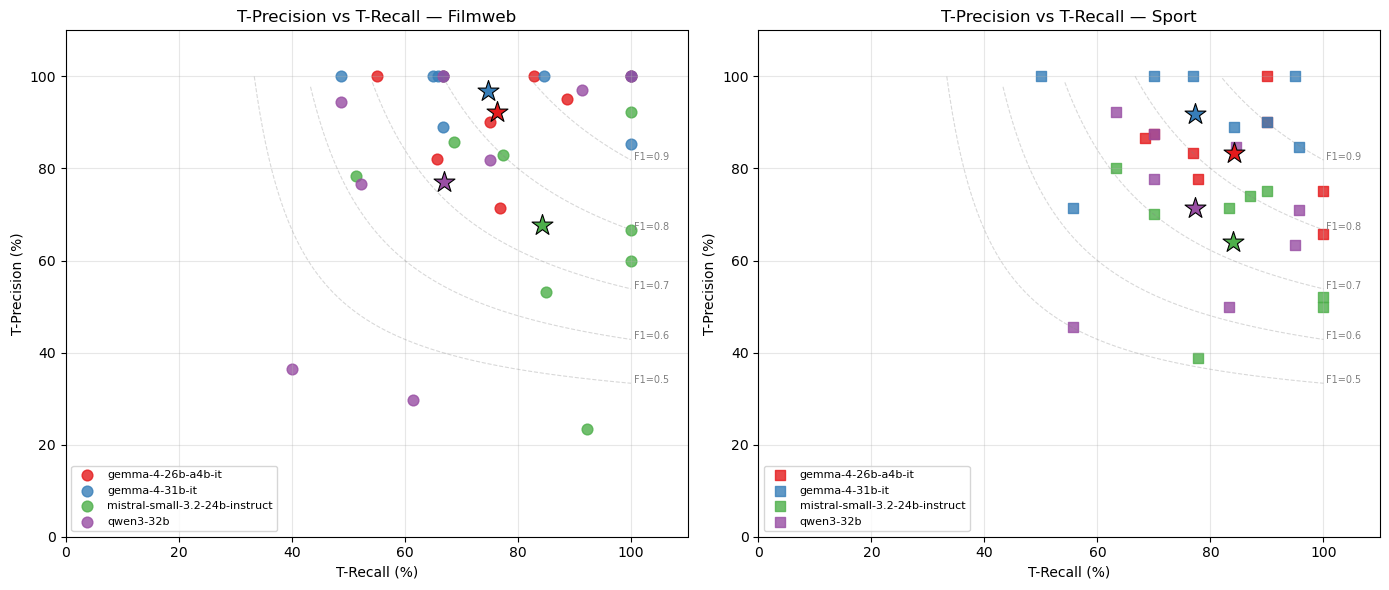

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
domain_markers = {"Filmweb": "o", "Sport": "s"}

for ax, domain in zip(axes, ["Filmweb", "Sport"]):
    sub = df[df["domain"] == domain]
    for m in TOP4:
        ms = short_label(m)
        rows = sub[sub["model_short"] == ms]
        ax.scatter(rows["t_recall"] * 100, rows["t_precision"] * 100,
                   c=MODEL_COLORS[m], marker=domain_markers[domain],
                   s=60, label=ms, alpha=0.8)
        # srednia
        ax.scatter(rows["t_recall"].mean() * 100, rows["t_precision"].mean() * 100,
                   c=MODEL_COLORS[m], marker="*", s=250,
                   edgecolors="black", linewidths=0.8, zorder=5)

    for f1 in [0.5, 0.6, 0.7, 0.8, 0.9]:
        r = np.linspace(0.01, 1, 200)
        p = f1 * r / (2 * r - f1)
        mask = (p > 0) & (p <= 1)
        ax.plot(r[mask] * 100, p[mask] * 100, "--", color="gray", alpha=0.3, linewidth=0.8)
        ax.text(r[mask][-1] * 100 + 0.5, p[mask][-1] * 100, f"F1={f1:.1f}", fontsize=7, color="gray")

    ax.set_xlim(0, 110)
    ax.set_ylim(0, 110)
    ax.set_xlabel("T-Recall (%)")
    ax.set_ylabel("T-Precision (%)")
    ax.set_title(f"T-Precision vs T-Recall — {domain}")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

fig.tight_layout()
plt.show()

## Wykres liniowy T-F1: trajektoria per artykuł (Sport)

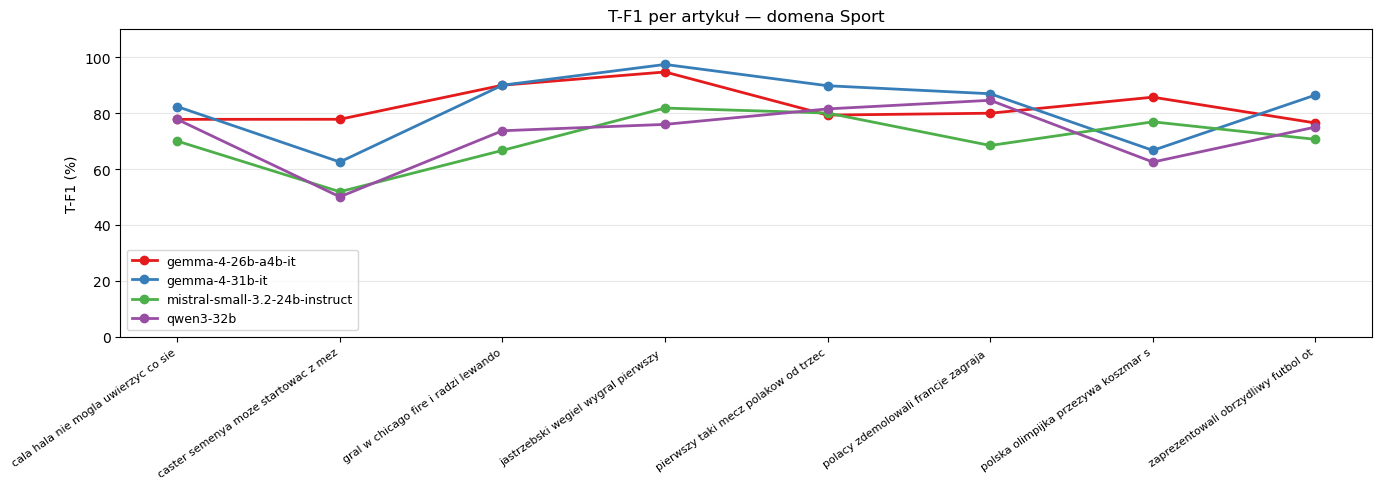

In [16]:
sport = df[df["domain"] == "Sport"]
article_order = sorted(sport["title_short"].unique())

fig, ax = plt.subplots(figsize=(14, 5))
for m in TOP4:
    ms = short_label(m)
    sub = sport[sport["model_short"] == ms].set_index("title_short")
    vals = [sub.loc[a, "t_f1"] * 100 if a in sub.index else np.nan for a in article_order]
    ax.plot(range(len(article_order)), vals, marker="o",
            label=ms, color=MODEL_COLORS[m], linewidth=2)

ax.set_xticks(range(len(article_order)))
ax.set_xticklabels([a[:35] for a in article_order], rotation=35, ha="right", fontsize=8)
ax.set_ylim(0, 110)
ax.set_ylabel("T-F1 (%)")
ax.set_title("T-F1 per artykuł — domena Sport")
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
plt.show()

## Ranking końcowy obu domen

In [18]:
rank_cols = ["precision", "t_precision", "t_recall", "t_f1"]
for domain in ["Filmweb", "Sport"]:
    display(HTML(f"<h4>Ranking — {domain} (wg T-F1)</h4>"))
    sub = df[df["domain"] == domain]
    r = sub.groupby("model_short")[rank_cols].mean().sort_values("t_f1", ascending=False).round(3)
    r["T-F1 rank"] = range(1, len(r)+1)
    display(
        r.style
        .background_gradient(subset=rank_cols, cmap="RdYlGn", vmin=0, vmax=1)
        .format({c: "{:.1%}" for c in rank_cols})
    )

,precision,t_precision,t_recall,t_f1,T-F1 rank
model_short,,,,,
gemma-4-31b-it,96.6%,96.8%,74.7%,83.0%,1
gemma-4-26b-a4b-it,97.5%,92.3%,76.4%,82.8%,2
mistral-small-3.2-24b-instruct,88.4%,67.8%,84.3%,71.5%,3
qwen3-32b,92.7%,77.0%,66.9%,69.6%,4


,precision,t_precision,t_recall,t_f1,T-F1 rank
model_short,,,,,
gemma-4-31b-it,89.4%,91.9%,77.2%,82.8%,1
gemma-4-26b-a4b-it,77.9%,83.2%,84.1%,82.7%,2
qwen3-32b,68.1%,71.5%,77.2%,72.6%,3
mistral-small-3.2-24b-instruct,67.8%,63.9%,83.9%,70.8%,4


## Wnioski

## Wnioski: czy wyniki generalizują się na nową domenę?

### Zestawienie metryk: Filmweb vs Sport

| Model | Prec. Filmweb | Prec. Sport | **ΔPrec** | T-F1 Filmweb | T-F1 Sport | **ΔT-F1** |
|---|---|---|---|---|---|---|
| gemma-4-26b-a4b-it | 97.5% | 77.9% | **−19.6 pp** | 82.8% | 82.7% | −0.1 pp |
| gemma-4-31b-it | 96.6% | 89.4% | −7.2 pp | 83.0% | 82.8% | −0.2 pp |
| mistral-small-3.2-24b-instruct | 88.4% | 67.8% | **−20.6 pp** | 71.5% | 70.8% | −0.7 pp |
| qwen3-32b | 92.7% | 68.1% | **−24.6 pp** | 69.6% | 72.6% | **+3.0 pp** |

Dane wskazują na **dwie odmienne narracje** w zależności od wybranej metryki.

---

### 1. Semantyczna jakość ekstrakcji (T-F1) — stabilna

T-F1 mierzy jakość relacji przez pryzmat podobieństwa semantycznego (sentence embeddings + algorytm węgierski względem grafu referencyjnego Opus). Różnice między domenami mieszczą się w granicach 0.1–3 pp, co dla n=8 artykułów należy traktować jako szum statystyczny.

**Wniosek**: modele LLM semantycznie rozumieją nową domenę bez żadnego dostrajania. Zdolność wydobywania właściwych informacji z tekstu jest domenowo niezależna.

Ranking modeli jest zachowany w obu domenach: gemma (oba warianty) > mistral ≈ qwen3-32b. Potwierdza to, że przewaga gemmy jest rzeczywista i domenowo niezależna — nie artefakt domeny filmweb.

---

### 2. Strukturalna precyzja (Precision) — wyraźnie niższa na sporcie

Precision spada o 7–25 pp w zależności od modelu. Interpretacja tego spadku wymaga ostrożności — są dwa współdziałające czynniki:

**Czynnik 1 — jakość promptu domenowego:**  
Prompt `filmweb_pl` był iteracyjnie dopracowywany przez wiele sesji testowych. Prompt `sport_pl` został zaprojektowany w jednej sesji. Sztywna lista dozwolonych typów relacji (`gra w`, `trenuje`, `pokonała` itp.) nie pokrywa wszystkich relacji pojawiających się w artykułach sportowych (rankingi, transfery, wyniki kontekstowe). Sędzia LLM-judge odrzuca relacje spoza listy jako niepotwierdzalne — obniżając Precision nawet gdy model wyekstrahował poprawną informację.

**Czynnik 2 — trudność domeny:**  
Sport zawiera więcej wieloznacznych, numerycznych i kontekstowych relacji niż filmweb (wyniki `3:1`, pozycje w tabeli, transfery, historia spotkań). Modele mają tendencję do ekstrapolowania tych relacji poza to, co wprost zostało podane w tekście.

---

### 3. Wniosek o uniwersalności rozwiązania

**Rozwiązanie jest warunkowo uniwersalne.**

- **Mocna strona**: zdolność modeli do semantycznej ekstrakcji grafów wiedzy generalizuje się między domenami — T-F1 jest stabilny. Nie jest wymagane dostrajanie modeli ani żadne dodatkowe uczenie.

- **Słaba strona**: strukturalna jakość ekstrakcji zależy silnie od jakości promptu domenowego. Bottleneck przy dodawaniu nowej domeny to **inżynieria promptu** — zdefiniowanie typów encji, typów relacji, przykładów pozytywnych i negatywnych — a nie zdolność modelu.

- **Implikacja praktyczna**: wdrożenie w nowej domenie wymaga jednorazowego nakładu na zaprojektowanie i iteracyjne testowanie promptu (analogicznie jak `filmweb_pl`). Wyniki dla sportu byłyby prawdopodobnie zbliżone do filmweb gdyby `sport_pl` przeszedł podobny proces iteracji. Jest to koszt akceptowalny i nie podważa wartości systemu — potwierdza jedynie, że jakość systemu koreluje z jakością promptu, nie z ograniczeniami modelu.

---

### 4. Dodatkowe obserwacje

**Connectivity wyższa dla sportu**: artykuły sportowe generują gęstsze grafy — jeden mecz łączy wiele encji (zawodnicy, drużyny, miejsca, wyniki), co naturalnie tworzy więcej połączeń w jednym komponencie spójności.

**qwen3-32b poprawia się na sporcie** (+3 pp T-F1): sugeruje że jego słabości obserwowane na filmweb były częściowo specyficzne dla tej domeny (prawdopodobnie mniej przykładów filmowych w danych treningowych modelu), podczas gdy tematyka sportowa jest reprezentowana lepiej.